# Wine Quality Classification — Model Training & Evaluation

**Course:** Machine Learning (AIMLCZG565) — Assignment 2
**Student:** Diksha Jain (2025AC05524)

This notebook trains **five classification models** on the UCI Wine Quality dataset
(red + white combined) and evaluates each with **six metrics**: Accuracy, AUC,
Precision, Recall, F1-score and Matthews Correlation Coefficient (MCC).

The fitted models and the scaler are saved to `*.joblib` for the Streamlit app,
and the held-out test rows are written to `../test_data.csv`.

## 1. Imports

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, roc_auc_score, precision_score,
    recall_score, f1_score, matthews_corrcoef, confusion_matrix,
    classification_report, RocCurveDisplay)

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
print("Libraries imported.")

Libraries imported.


## 2. Load dataset (UCI Wine Quality: red + white)

In [2]:
RED_URL   = "https://archive.ics.uci.edu/ml/machine-learning-databases/wine-quality/winequality-red.csv"
WHITE_URL = "https://archive.ics.uci.edu/ml/machine-learning-databases/wine-quality/winequality-white.csv"

red   = pd.read_csv(RED_URL, sep=";")
white = pd.read_csv(WHITE_URL, sep=";")
red["wine_type"]   = 0   # 0 = red
white["wine_type"] = 1   # 1 = white
df = pd.concat([red, white], ignore_index=True)

# Binary target: "good" wine if the sensory quality rating is 7 or higher.
df["good"] = (df["quality"] >= 7).astype(int)
df = df.drop(columns=["quality"])

print("Shape:", df.shape, "| features:", df.shape[1]-1, "| instances:", df.shape[0])
df.head()

Shape: (6497, 13) | features: 12 | instances: 6497


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,wine_type,good
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,0,0
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,0,0
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,0,0
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,0,0
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,0,0


## 3. Exploratory checks

In [3]:
print("Class balance (good = quality>=7):")
print(df["good"].value_counts())
print("Positive rate:", round(df["good"].mean(), 3))

feature_cols = [c for c in df.columns if c != "good"]
print("\n12 feature columns:")
print(feature_cols)

Class balance (good = quality>=7):
good
0    5220
1    1277
Name: count, dtype: int64
Positive rate: 0.197

12 feature columns:
['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar', 'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density', 'pH', 'sulphates', 'alcohol', 'wine_type']


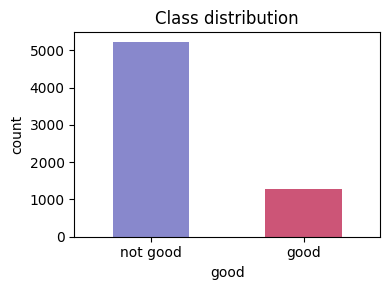

In [4]:
# Class distribution plot
plt.figure(figsize=(4,3))
df["good"].value_counts().sort_index().plot(kind="bar", color=["#8888cc","#cc5577"])
plt.xticks([0,1], ["not good","good"], rotation=0)
plt.title("Class distribution"); plt.ylabel("count"); plt.tight_layout(); plt.show()

## 4. Train/test split + scaling

In [5]:
X = df[feature_cols].values
y = df["good"].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=RANDOM_STATE, stratify=y)

scaler = StandardScaler().fit(X_train)
X_train_s = scaler.transform(X_train)
X_test_s  = scaler.transform(X_test)

print("Train:", X_train_s.shape, "| Test:", X_test_s.shape)

Train: (5197, 12) | Test: (1300, 12)


## 5. Train the five models

In [6]:
models = {
    "Logistic Regression":      LogisticRegression(max_iter=2000, random_state=RANDOM_STATE),
    "Decision Tree":            DecisionTreeClassifier(max_depth=8, random_state=RANDOM_STATE),
    "kNN":                      KNeighborsClassifier(n_neighbors=15),
    "Naive Bayes":              GaussianNB(),
    "Random Forest (Ensemble)": RandomForestClassifier(n_estimators=300, random_state=RANDOM_STATE, n_jobs=-1),
}

for name, m in models.items():
    m.fit(X_train_s, y_train)
print("All 5 models trained.")

All 5 models trained.


## 6. Evaluate — six metrics per model

In [7]:
def evaluate(model, X, y):
    y_pred = model.predict(X)
    y_score = model.predict_proba(X)[:,1] if hasattr(model,"predict_proba") else model.decision_function(X)
    return {
        "Accuracy":  accuracy_score(y, y_pred),
        "AUC":       roc_auc_score(y, y_score),
        "Precision": precision_score(y, y_pred, zero_division=0),
        "Recall":    recall_score(y, y_pred, zero_division=0),
        "F1":        f1_score(y, y_pred, zero_division=0),
        "MCC":       matthews_corrcoef(y, y_pred),
    }

results = {name: evaluate(m, X_test_s, y_test) for name, m in models.items()}
table = pd.DataFrame(results).T[["Accuracy","AUC","Precision","Recall","F1","MCC"]].round(4)
print("Metric comparison (test set):")
table

Metric comparison (test set):


,Accuracy,AUC,Precision,Recall,F1,MCC
Logistic Regression,0.8223,0.8048,0.6147,0.2617,0.3671,0.3178
Decision Tree,0.8354,0.8180,0.6000,0.4922,0.5408,0.4449
kNN,0.8246,0.8306,0.5745,0.4219,0.4865,0.3904
Naive Bayes,0.7346,0.7486,0.3901,0.6172,0.4781,0.3268
Random Forest (Ensemble),0.8892,0.9165,0.8077,0.5742,0.6712,0.6197


In [8]:
print("Overall winner (by MCC):", table["MCC"].idxmax())

Overall winner (by MCC): Random Forest (Ensemble)


## 7. Confusion matrices

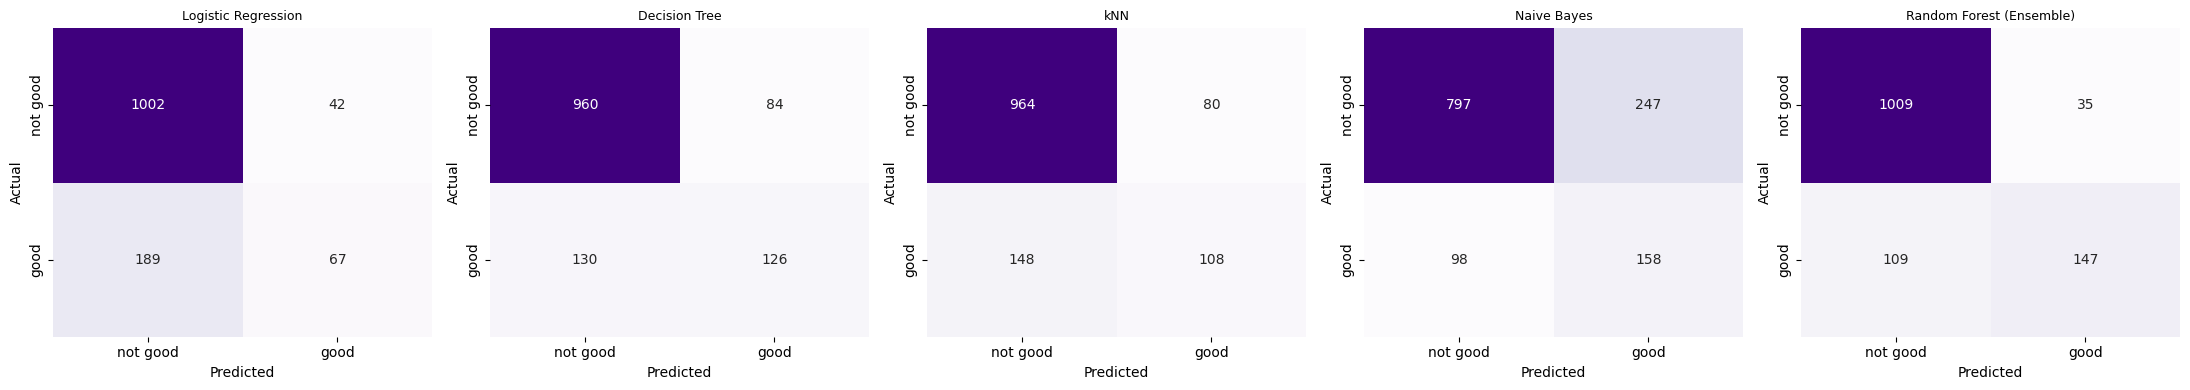

In [9]:
fig, axes = plt.subplots(1, 5, figsize=(22, 4))
for ax, (name, m) in zip(axes, models.items()):
    cm = confusion_matrix(y_test, m.predict(X_test_s))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Purples", cbar=False,
                xticklabels=["not good","good"], yticklabels=["not good","good"], ax=ax)
    ax.set_title(name, fontsize=9); ax.set_xlabel("Predicted"); ax.set_ylabel("Actual")
plt.tight_layout(); plt.show()

## 8. ROC curves

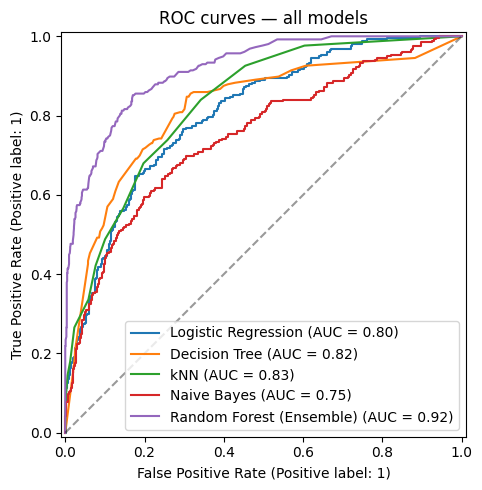

In [10]:
plt.figure(figsize=(6,5))
ax = plt.gca()
for name, m in models.items():
    RocCurveDisplay.from_estimator(m, X_test_s, y_test, name=name, ax=ax)
plt.plot([0,1],[0,1],'k--',alpha=0.4)
plt.title("ROC curves — all models"); plt.tight_layout(); plt.show()

## 9. Save test data (for the Streamlit app)


In [11]:
# Save the held-out test rows for the Streamlit app + submission.
# NOTE: we deliberately do NOT pickle the models. They train in <1s, so the
# Streamlit app re-trains them on startup instead of loading large *.joblib files
# (keeps the repo light and avoids sklearn version-mismatch errors on the cloud).
import os
REPO = os.path.dirname(os.getcwd())      # repo root (parent of model/)
test_df = pd.DataFrame(X_test, columns=feature_cols)
test_df["good"] = y_test
test_df.to_csv(os.path.join(REPO, "test_data.csv"), index=False)
print("Saved test_data.csv (", len(test_df), "rows ) to repo root.")

Saved test_data.csv ( 1300 rows ) to repo root.
